In [1]:

import os

# Prevent Jupyter/Anaconda from crashing when duplicate Intel OpenMP runtimes are loaded.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

import torch
import torch.nn as nn
import torch.optim as optim 
import torchvision.transforms as transforms
from torch.utils.data import DataLoader 
import copy
import random
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import torchvision


In [2]:
# CPU-only run: this notebook uses the Anaconda base kernel, where PyTorch is installed as a CPU build.
device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cpu


In [3]:
cifar100_mean=(0.5071,0.4867,0.4408)
cifar100_std=(0.2675,0.2565,0.2761)

In [4]:
train_transform=transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(cifar100_mean,cifar100_std)
])

val_transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar100_mean,cifar100_std)
])

    

In [5]:
all_target_class=[
    'orchid','poppy','rose','sunflower','tulip',
    'fox','porcupine','possum','raccoon','skunk',
    'bee','bettle','butterfly','caterpillar','cockroach'
]


In [6]:
def load_cifar100_subset(target_classes, train_transform, val_transform, root='./cifar_100'):

    # Construct the path to the CIFAR-100 dataset directory.
    cifar100_path = os.path.join(root, 'cifar-100-python')
    # Check if the dataset directory exists locally.
    if os.path.isdir(cifar100_path):
        print(f"Dataset found in '{root}'. Loading from local files.")
    # If not found, inform the user that it will be downloaded.
    else:
        print(f"Dataset not found in '{root}'. Downloading...")

    # Load the full CIFAR-100 training dataset.
    train_dataset_full = torchvision.datasets.CIFAR100(
        root=root, 
        train=True, 
        download=True, 
        transform=train_transform
    )

    # Load the full CIFAR-100 test dataset.
    test_dataset_full = torchvision.datasets.CIFAR100(
        root=root, 
        train=False, 
        download=True, 
        transform=val_transform
    )
    print("Dataset loaded successfully.")

    # Get the list of all class names from the dataset.
    all_classes = train_dataset_full.classes
    try:
        # Get the original integer indices for the target class names.
        target_indices = [all_classes.index(cls) for cls in target_classes]
    # Handle the case where a specified class name is not in the dataset.
    except ValueError as e:
        print(f"Error: One of the target classes not found in CIFAR-100. {e}")
        return None, None
        
    # Create a mapping from the original class indices to new, contiguous indices (0, 1, 2, ...).
    label_map = {old_label: new_label for new_label, old_label in enumerate(target_indices)}

    # Define a helper function to filter a dataset based on the target classes.
    def _filter_dataset(dataset):
        # Convert the list of targets to a NumPy array for efficient boolean indexing.
        targets_np = np.array(dataset.targets)
        # Create a boolean mask to identify which samples belong to the target classes.
        indices_to_keep = np.isin(targets_np, target_indices)
        
        # Filter the dataset's image data using the boolean mask.
        dataset.data = dataset.data[indices_to_keep]
        
        # Get the original labels of the samples that are being kept.
        original_targets_to_keep = targets_np[indices_to_keep]
        # Remap the original labels to the new contiguous labels.
        dataset.targets = [label_map[target] for target in original_targets_to_keep]
        
        # Update the dataset's class list to only include the target classes.
        dataset.classes = target_classes
        return dataset

    print(f"\nFiltering for {len(target_classes)} classes...")
    # Apply the filtering logic to the full training dataset.
    train_dataset_subset = _filter_dataset(train_dataset_full)
    # Apply the filtering logic to the full test dataset.
    test_dataset_subset = _filter_dataset(test_dataset_full)
    print("Filtering complete. Returning training and validation datasets.")
    
    # Return the filtered training and test subsets.
    return train_dataset_subset, test_dataset_subset



In [7]:
def visualise_images(dataset, grid):
    """
    Displays a grid of images from a dataset, with one random image per class.

    Args:
        dataset: The dataset object containing the images and labels.
        grid (tuple): A tuple specifying the number of rows and columns for the image grid.
    """

    # Create a shallow copy of the dataset to avoid modifying the original
    dataset_copy = copy.copy(dataset)
    # Set the transform on the copied dataset to convert images to tensors
    dataset_copy.transform = torchvision.transforms.ToTensor()

    # Create a DataLoader to handle batching and shuffling of the data
    loader = DataLoader(dataset_copy, batch_size=64, shuffle=True)

    # Unpack the grid dimensions from the input tuple
    rows, cols = grid
    # Calculate the total number of images to display in the grid
    num_images_to_show = rows * cols

    # Get the dataset object from the DataLoader
    dataset_to_show = loader.dataset

    # Create a dictionary to store lists of indices for each class
    class_indices = defaultdict(list)
    # Iterate through the dataset to populate the class_indices dictionary
    for idx, target in enumerate(dataset_to_show.targets):
        class_indices[target].append(idx)
        
    # Get the list of class names from the dataset
    class_names = dataset_to_show.classes

    # Create a figure and a set of subplots for the grid layout
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))

    # Iterate over each subplot in the grid
    for i, ax in enumerate(axes.flat):
        # If the current index is out of bounds, turn off the subplot axis
        if i >= num_images_to_show or i >= len(class_names):
            ax.axis('off')
            continue
            
        # Set the class label based on the current iteration index
        class_label = i
        
        # Get the list of image indices for the current class
        indices_for_class = class_indices[class_label]
        # If there are no images for this class, turn off the subplot axis
        if not indices_for_class:
            ax.axis('off')
            continue

        # Choose a random image index from the list for the current class
        random_image_index = random.choice(indices_for_class)
        
        # Retrieve the image tensor and its corresponding label from the dataset
        image_tensor, _ = dataset_to_show[random_image_index]
        
        # Convert the tensor to a NumPy array and transpose dimensions for display
        img_to_display = image_tensor.numpy().transpose((1, 2, 0))
        
        # Get the name of the class corresponding to the class label
        class_name = class_names[class_label]
        
        # Display the image on the current subplot
        ax.imshow(img_to_display)
        
        # Set the title of the subplot to the capitalized class name
        ax.set_title(class_name.capitalize(), fontsize=16)
        # Turn off the axis for a cleaner look
        ax.axis('off')

    # Adjust subplot parameters for a tight layout
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    # Display the plot
    plt.show()

    # Clean up the copied dataset to free up memory
    del dataset_copy
    
    


In [8]:
def visualise_predictions(model, data_loader, device, grid):
    # Set the model to evaluation mode
    model.eval()

    # Get the dataset and class names from the data loader
    dataset = data_loader.dataset
    class_names = dataset.classes
    
    # Define mean and standard deviation values for de-normalizing the images
    cifar100_mean = np.array([0.5071, 0.4867, 0.4408])
    cifar100_std = np.array([0.2675, 0.2565, 0.2761])
    
    # Create a dictionary to store lists of indices for each class
    class_indices = defaultdict(list)
    # Iterate through the dataset to populate the class_indices dictionary
    for idx, target in enumerate(dataset.targets):
        class_indices[target].append(idx)
        
    # Unpack the grid dimensions
    rows, cols = grid
    # Calculate the total number of images to display
    num_images_to_show = rows * cols
    
    # Create a figure and a set of subplots
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2)) 
    # Adjust the spacing between subplots
    plt.subplots_adjust(wspace=0.3, hspace=0.8)

    # Iterate over each subplot in the grid
    for i, ax in enumerate(axes.flat):
        # If the current index is out of bounds, turn off the subplot axis
        if i >= num_images_to_show or i >= len(class_names):
            ax.axis('off')
            continue
            
        # Set the class label based on the current iteration index
        class_label = i
        
        # Get the list of image indices for the current class
        indices_for_class = class_indices[class_label]
        # If there are no images for this class, turn off the subplot axis
        if not indices_for_class:
            ax.axis('off')
            continue

        # Choose a random image index from the list for the current class
        random_image_index = random.choice(indices_for_class)
        # Retrieve the image tensor and its true label
        image_tensor, true_label = dataset[random_image_index]
        
        # Add a batch dimension and move the tensor to the specified device
        image_batch = image_tensor.unsqueeze(0).to(device)
        
        # Disable gradient calculations for inference
        with torch.no_grad():
            # Get model predictions
            output = model(image_batch)
            # Find the index of the highest score, which is the predicted class
            _, predicted_index = torch.max(output, 1)
        
        # Extract the predicted label as a Python number
        predicted_label = predicted_index.item()
        
        # Convert tensor to a NumPy array and transpose dimensions for display
        img_np = image_tensor.cpu().numpy().transpose((1, 2, 0))
        # De-normalize the image using the predefined mean and std
        denormalized_img = cifar100_std * img_np + cifar100_mean
        # Clip the pixel values to the valid range [0, 1]
        clipped_img = np.clip(denormalized_img, 0, 1)
        
        # Get the string names for the true and predicted labels
        true_name = class_names[true_label]
        predicted_name = class_names[predicted_label]
        
        # Set the title color to green for correct predictions and red for incorrect ones
        title_color = 'green' if true_label == predicted_label else 'red'
        
        # Display the image
        ax.imshow(clipped_img)
        # Set the title with true and predicted labels
        ax.set_title(f"True: {true_name.capitalize()}\nPred: {predicted_name.capitalize()}", 
                     color=title_color, fontsize=10, pad=5)
        # Turn off the axis
        ax.axis('off')

    # Adjust subplot parameters for a tight layout
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    # Show the final plot
    plt.show()

In [9]:
def plot_training_metrics(metrics):
    """
    Plots the training and validation metrics from a model training process.

    This function generates two side-by-side plots:
    1. Training Loss vs. Validation Loss.
    2. Validation Accuracy.

    Args:
        metrics (list): A list or tuple containing three lists:
                        [train_losses, val_losses, val_accuracies].
    """
    # Unpack the metrics into their respective lists
    train_losses, val_losses, val_accuracies = metrics
    
    # Determine the number of epochs from the length of the training losses list
    num_epochs = len(train_losses)
    # Create a 1-indexed range of epoch numbers for the x-axis
    epochs = range(1, num_epochs + 1)

    # Create a figure and a set of subplots with 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # --- Configure the first subplot for training and validation loss ---
    # Select the first subplot
    ax1 = axes[0]
    # Plot training loss data
    ax1.plot(epochs, train_losses, color='#085c75', linewidth=2.5, marker='o', markersize=5, label='Training Loss')
    # Plot validation loss data
    ax1.plot(epochs, val_losses, color='#fa5f64', linewidth=2.5, marker='o', markersize=5, label='Validation Loss')
    # Set the title and axis labels for the loss plot
    ax1.set_title('Training & Validation Loss', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    # Display the legend
    ax1.legend()
    # Add a grid for better readability
    ax1.grid(True, linestyle='--', alpha=0.6)

    # --- Configure the second subplot for validation accuracy ---
    # Select the second subplot
    ax2 = axes[1]
    # Plot validation accuracy data
    ax2.plot(epochs, val_accuracies, color='#fa5f64', linewidth=2.5, marker='o', markersize=5, label='Validation Accuracy')
    # Set the title and axis labels for the accuracy plot
    ax2.set_title('Validation Accuracy', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    # Display the legend
    ax2.legend()
    # Add a grid for better readability
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    # --- Apply dynamic and consistent styling to both subplots ---
    # Calculate a suitable interval for the x-axis ticks to avoid clutter
    x_interval = (num_epochs - 1) // 10 + 1

    # Loop through each subplot to apply common axis settings
    for ax in axes:
        # Set the y-axis to start at 0 and the x-axis to span the epochs
        ax.set_ylim(bottom=0)
        ax.set_xlim(left=1, right=num_epochs)
        
        # Set the major tick locator for the x-axis using the dynamic interval
        ax.xaxis.set_major_locator(mticker.MultipleLocator(x_interval))
        # Set the font size for the tick labels on both axes
        ax.tick_params(axis='both', which='major', labelsize=10)

    # Adjust subplot parameters for a tight layout
    plt.tight_layout()
    # Display the plots
    plt.show()
    
    

In [10]:
class SimpleCNN(nn.Module):
    def __init__(self,num_classes):
        super(SimpleCNN,self).__init__()

        self.conv1=nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,padding=1)
        self.relu1=nn.ReLU()
        self.pool1=nn.MaxPool2d(kernel_size=2,stride=2)

        self.conv2=nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding=1)
        self.relu2=nn.ReLU()
        self.pool2=nn.MaxPool2d(kernel_size=2,stride=2)

        self.conv3=nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,padding=1)
        self.relu3=nn.ReLU()
        self.pool3=nn.MaxPool2d(kernel_size=2,stride=2)

        self.flatten=nn.Flatten()

        self.fc1=nn.Linear(128*4*4,512)
        self.relu4=nn.ReLU()
        self.dropout=nn.Dropout(0.5)
        self.fc2=nn.Linear(512,num_classes)

    def forward(self,x):

        x=self.conv1(x)
        x=self.relu1(x)
        x=self.pool1(x)

        x=self.conv2(x)
        x=self.relu2(x)
        x=self.pool2(x)

        x=self.conv3(x)
        x=self.relu3(x)
        x=self.pool3(x)

        x=self.flatten(x)

        x = self.fc1(x)
        x = self.relu4(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

        
    

In [11]:
def training_loop(model,train_loader,val_loader,loss_function,optimizer,num_epochs,device):
    model.to(device)

    train_losses=[]
    val_losses=[]
    val_accuracies=[]

    for epoch in range(num_epochs):
        model.train()
        running_loss=0.0
        for images,labels in train_loader:
            images,labels=images.to(device),labels.to(device)

            optimizer.zero_grad()
            outputs=model(images)
            loss=loss_function(outputs,labels)
            loss.backward()
            optimizer.step()
            running_loss+=loss.item()*images.size(0)
        epoch_loss=running_loss/len(train_loader.dataset)
        train_losses.append(epoch_loss)

        model.eval()
        running_val_loss=0.0
        correct=0
        total=0
        with torch.no_grad():
            for images,labels in val_loader:
                images,labels=images.to(device),labels.to(device)
                outputs=model(images)
                val_loss=loss_function(outputs,labels)
                running_val_loss+=val_loss.item()*images.size(0)
                _,predicted=torch.max(outputs,1)
                total+=labels.size(0)
                correct+=(predicted==labels).sum().item()
        epoch_val_loss=running_val_loss/len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        epoch_accuracy=100*correct/total
        val_accuracies.append(epoch_accuracy)

        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {epoch_accuracy:.2f}%")


    metrics=[train_losses,val_losses,val_accuracies]
    return model,metrics
        
        
        


In [12]:
# Define the full class list.
all_target_classes = [
    # Flowers
    'orchid', 'poppy', 'rose', 'sunflower', 'tulip',
    # Mammals
    'fox', 'porcupine', 'possum', 'raccoon', 'skunk',
    # Insects
    'bee', 'beetle', 'butterfly', 'caterpillar', 'cockroach'
]

# Load the full datasets.
train_dataset, val_dataset =load_cifar100_subset(all_target_classes, train_transform, val_transform)

Dataset found in './cifar_100'. Loading from local files.
Dataset loaded successfully.

Filtering for 15 classes...
Filtering complete. Returning training and validation datasets.


Dataset loaded successfully.

Filtering for 15 classes...
Filtering complete. Returning training and validation datasets.


In [13]:
batch_size=16
train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=batch_size,shuffle=False)


In [14]:
num_classes=len(train_dataset.classes)
model=SimpleCNN(num_classes)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=15, bias=True)
)


In [15]:
optimizer=optim.Adam(model.parameters(),lr=0.001)
loss_function=nn.CrossEntropyLoss()

Epoch [1/25], Train Loss: 2.1103, Val Loss: 1.6993, Val Accuracy: 42.53%
Epoch [2/25], Train Loss: 1.7056, Val Loss: 1.4900, Val Accuracy: 51.47%


Epoch [3/25], Train Loss: 1.5606, Val Loss: 1.4668, Val Accuracy: 52.13%


Epoch [4/25], Train Loss: 1.4402, Val Loss: 1.3048, Val Accuracy: 55.20%


Epoch [5/25], Train Loss: 1.3499, Val Loss: 1.2695, Val Accuracy: 57.20%


Epoch [6/25], Train Loss: 1.2683, Val Loss: 1.2001, Val Accuracy: 59.33%


...

Epoch [21/25], Train Loss: 0.6701, Val Loss: 1.1263, Val Accuracy: 66.13%


Epoch [22/25], Train Loss: 0.6500, Val Loss: 1.1451, Val Accuracy: 65.93%


Epoch [23/25], Train Loss: 0.6445, Val Loss: 1.1599, Val Accuracy: 66.00%


Epoch [24/25], Train Loss: 0.5916, Val Loss: 1.2042, Val Accuracy: 65.13%


Epoch [25/25], Train Loss: 0.5932, Val Loss: 1.2165, Val Accuracy: 66.00%


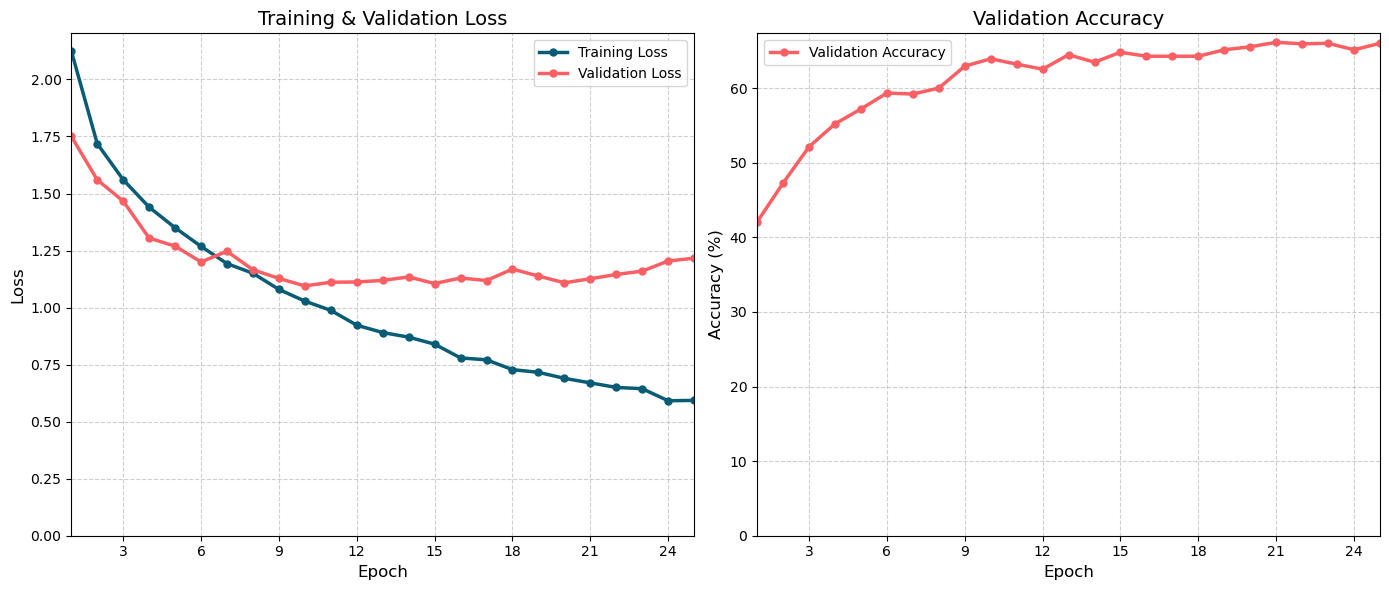

In [ ]:
trained_model,training_metrics=training_loop(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    num_epochs=25,
    device=device
)

plot_training_metrics(training_metrics)

In [ ]:
visualise_predictions(
     model=trained_model, 
     data_loader=val_loader, 
    device=device, 
     grid=(3, 5)
 )

In [ ]:
import os
import torch

PROJECT_ROOT = os.path.abspath("..")
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
MODEL_PATH = os.path.join(MODEL_DIR, "nature_cnn.pth")

os.makedirs(MODEL_DIR, exist_ok=True)

torch.save(trained_model.state_dict(), MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")